<a href="https://colab.research.google.com/github/hyo04/DL_Final/blob/main/10_Data_Classification_YOLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏠 Data collection and classification Challenge — YOLOv8

**Objective:** You have been hired as an AI expert and your new boss, who knows nothing about AI, asked you to quickly develop a DL model that can classify roofs in the UK from aerial views. The input is in the form of image crops from Google satellite views, each containing one building. Some crops may contain a few buildings but it can be considered as noise. You should collect data and finetune `yolov8n-cls.pt`  model.   Classify aerial roof images into **flat** or **pitched**. These are the constraints, otherwise you are free to make your own design choices.

- Tune training hyperparameters  
- Add more images to improve your model  
- Experiment with augmentation or optimization settings  

When you are satisfied, submit the annotated data `*CID*_data.zip` with the same file structure as the provided sample as well as your best `*CID*_best.pt` checkpoint, which will be evaluated on a hidden test set. Keep the filenames of the existing samples as they are.

---

### 📁 Expected dataset structure
<pre>
.../aerial
├─ train/
│ ├─ flat/
│ └─ pitched/
├─ val/
│ ├─ flat/
│ └─ pitched/
└─ test/
  ├─ flat/
  └─ pitched/
</pre>

---

### 📌 Notes

- You will train only the classification model `yolov8n-cls.pt`.

- Image size (`imgsz`):  
  - YOLOv8 automatically resizes any input to the `imgsz` you set in `model.train(...)`.  
  - Tip: using sizes that are multiples of 32 (224, 256, 320, 384, …) aligns well with the backbone. Larger sizes train slower, but can perform better.
  - When collecting images, there’s no strict size rule; just aim for **clear roofs**.

- Collecting more images:
  - Sources: **Google Earth**, **OpenAerialMap**, **Mapillary**, **Kaggle**, public GIS/satellite portals, or your **own drone/photos**.  
  - Prefer images that aren’t tiny/blurry/over-compressed. RGB `.jpg/.jpeg/.png/.bmp/.webp` are all fine.

- Adding new data to `/aerial`:
  1. Label by roof type and drop files into the correct folders locally:
     ```
     aerial/
     ├─ train/
     │  ├─ flat/
     │  └─ pitched/
     ├─ val/
     │  ├─ flat/
     │  └─ pitched/
     └─ test/
        ├─ flat/
        └─ pitched/
     ```
  2. Do **not** duplicate the same image across `train/`, `val/`, and `test/`.
  3. Compress local folder to [aerial.zip](https://github.com/MatchLab-Imperial/deep-learning-course/blob/master/asset/10_Classification_YOLO/aerial.zip) to upload to colab in the code block below.



In [1]:
!pip install -q ultralytics  # uncomment if not installed

from ultralytics import YOLO
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random, torch

from google.colab import files
uploaded = files.upload()  # choose aerial.zip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Saving aerial.zip to aerial.zip


In [2]:
!unzip -q -o aerial.zip -d /content/
!find /content/aerial -maxdepth 2 -type d -print  # quick check

/content/aerial
/content/aerial/val
/content/aerial/val/flat
/content/aerial/val/pitched
/content/aerial/test
/content/aerial/test/flat
/content/aerial/test/pitched
/content/aerial/train
/content/aerial/train/flat
/content/aerial/train/pitched


Classes: ['flat', 'pitched']


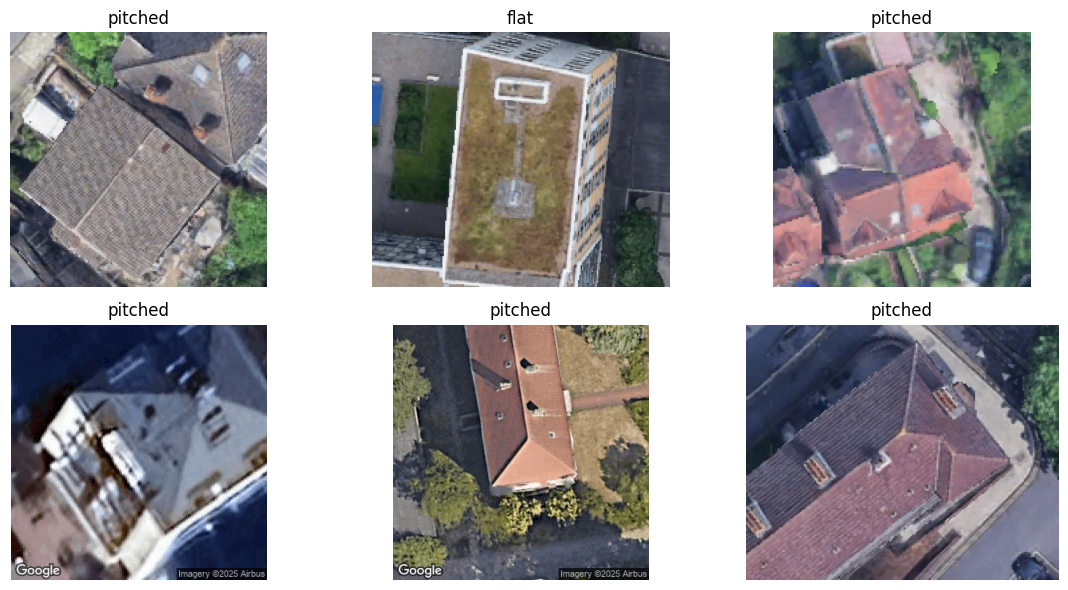

In [3]:
DATA_ROOT = Path("/content/aerial")
assert (DATA_ROOT/"train").exists() and (DATA_ROOT/"val").exists(), "train/val folders missing"

# List classes from train/
classes = sorted([p.name for p in (DATA_ROOT/"train").iterdir() if p.is_dir()])
print("Classes:", classes)

# Collect sample images
exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
samples = []
for cls in classes:
    samples += [p for p in (DATA_ROOT/"train"/cls).iterdir() if p.suffix.lower() in exts]

random.shuffle(samples)
show = samples[:6]

# Plot
cols = 3
rows = 2
plt.figure(figsize=(12, 6))
for i, p in enumerate(show, 1):
    img = Image.open(p)
    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.title(p.parent.name)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 🛠 Training Tips — Things You Can Try

You may experiment with these arguments in `model.train()`:

| Parameter | Meaning | Suggested values |
|-----------|---------|------------------|
| `imgsz` | input image size | `224`, `320`, `384` |
| `epochs` | training duration | `10–60` |
| `batch` | batch size | `16–128` |
| `auto_augment` | built-in augmentation | `"randaugment"`, `"ta_wide"` |
| `mixup` / `cutmix` | label mixing | `0.0–0.3` |
| `erasing` | random erasing | `0.0–0.7` |
| `optimizer` | optimizer choice | `"SGD"` or `"AdamW"` |
| `cos_lr` | cosine LR schedule | `True` or `False` |

Tip: only change one or two things at a time, and always monitor `top1_acc`. (`top5_acc` is printed automatically in YOLO classification tasks, but is useless in our two-class task.)


In [14]:
DATA_ROOT = Path("/content/aerial")
assert (DATA_ROOT/"train").exists(), "train folder missing"
assert (DATA_ROOT/"val").exists(), "val folder missing"
assert (DATA_ROOT/"test").exists(), "test folder missing"

device = 0 if torch.cuda.is_available() else "cpu"

model = YOLO("yolov8s-cls.pt")  #upgrade from nano→small for more capacity

results = model.train(
    data=str(DATA_ROOT),
    imgsz=384,                   #larger-> more roof detail visible
    epochs=60,
    batch=32,
    device=device,
    workers=2,
    patience=15,
    auto_augment="randaugment",
    erasing=0.4,
    mixup=0.2,
    cutmix=0.2,
    optimizer="AdamW",
    cos_lr=True,
    lr0=5e-4,                    #lower LR for better fine-tuning
    lrf=0.01,
    weight_decay=1e-4,
    warmup_epochs=5,
    dropout=0.3,
    verbose=False,
    plots=False,
)

best_ckpt = model.trainer.best
print("Best checkpoint to submit:", best_ckpt)

# ======== TEST (held-out split) ========
metrics = model.val(
    data=str(DATA_ROOT),
    split="test",
    imgsz=320,
    device=device,
    verbose=False,           # <-- minimising console output
)
print(f"Test: {100*metrics.top1:.4f}%")


Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.2, data=/content/aerial, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.3, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=384, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8s-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train8, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=15, perspective=0.0, plots

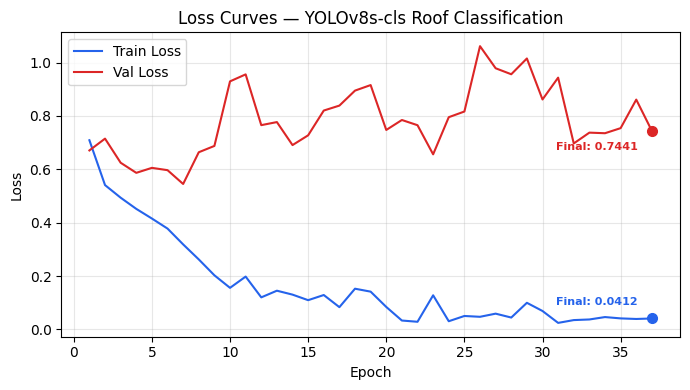

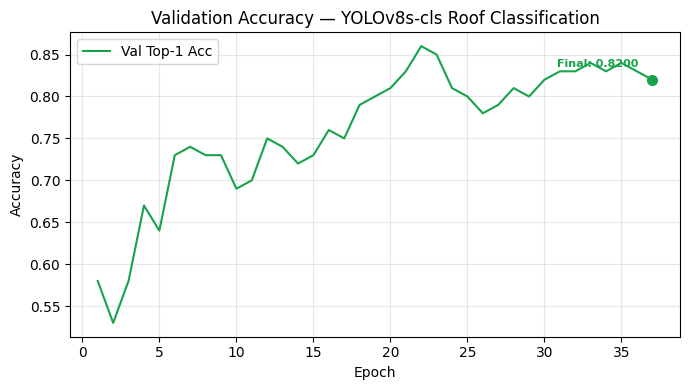


Classification Report:
              precision    recall  f1-score   support

        flat       0.81      0.88      0.84        40
     pitched       0.86      0.80      0.83        40

    accuracy                           0.84        80
   macro avg       0.84      0.84      0.84        80
weighted avg       0.84      0.84      0.84        80



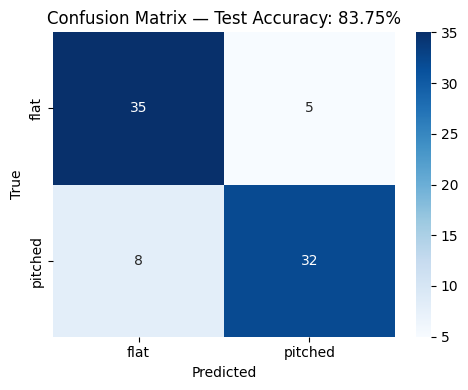

In [19]:
# ======== PERFORMANCE REPORT ========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

classes = ["flat", "pitched"]
exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

results_csv = Path(model.trainer.save_dir) / "results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

# ── Loss Curve ──
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df["epoch"], df["train/loss"], label="Train Loss", color="#2563eb")
ax.plot(df["epoch"], df["val/loss"],   label="Val Loss",   color="#dc2626")

final_epoch = df["epoch"].iloc[-1]
for col, color, va in [("train/loss", "#2563eb", "bottom"), ("val/loss", "#dc2626", "top")]:
    final_val = df[col].iloc[-1]
    ax.plot(final_epoch, final_val, "o", color=color, markersize=7, zorder=5)
    ax.annotate(f"Final: {final_val:.4f}", xy=(final_epoch, final_val),
                xytext=(-10, 8 if va == "bottom" else -8),
                textcoords="offset points",
                fontsize=8, color=color, va=va, ha="right",
                fontweight="bold")

ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Loss Curves — YOLOv8s-cls Roof Classification")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Validation Accuracy Curve ──
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df["epoch"], df["metrics/accuracy_top1"], label="Val Top-1 Acc", color="#16a34a")

final_acc = df["metrics/accuracy_top1"].iloc[-1]
ax.plot(final_epoch, final_acc, "o", color="#16a34a", markersize=7, zorder=5)
ax.annotate(f"Final: {final_acc:.4f}", xy=(final_epoch, final_acc),
            xytext=(-10, 8),
            textcoords="offset points",
            fontsize=8, color="#16a34a", va="bottom", ha="right",
            fontweight="bold")

ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.set_title("Validation Accuracy — YOLOv8s-cls Roof Classification")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
# ── Confusion Matrix ──
best_model = YOLO(str(best_ckpt))
y_true, y_pred = [], []

for cls in classes:
    for img_path in (DATA_ROOT / "test" / cls).iterdir():
        if img_path.suffix.lower() not in exts:
            continue
        pred = best_model.predict(str(img_path), verbose=False, imgsz=320)[0]
        y_true.append(cls)
        y_pred.append(classes[pred.probs.top1])

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred, labels=classes)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes,
            cmap="Blues", ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix — Test Accuracy: {100*metrics.top1:.2f}%")
plt.tight_layout()
plt.show()

### 💾 Saving and Submitting Your Model

**Report**:

*   Report the classification performance you achieved.
*   Present details of your training data and training parameters such that someone can reproduce your experiment.
*   Include a figure with the learning curves.

Once training is complete, you’ll download your best-performing model checkpoint for submission.  

Follow the short prompt below to enter your **CID** — this will automatically rename your `best.pt` file (to `*CID*_best.pt`) and trigger the download.



In [20]:
import re, shutil

# Ensuring best_ckpt exists
assert 'best_ckpt' in globals(), "Run the training cell first to define `best_ckpt`."
src = Path(best_ckpt)
assert src.exists(), f"Checkpoint not found at: {src}"


cid = input("Enter your College ID: ").strip()
cid = re.sub(r'[^0-9]', '', cid)
if not cid:
    raise ValueError("Invalid College ID. Please use digits only (0–9).")


dst = Path(f"/content/{cid}_best.pt")
shutil.copy(src, dst)
print(f"Prepared submission file: {dst}")

# Downloading
files.download(str(dst))

Enter your College ID: 02408165
Prepared submission file: /content/02408165_best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>